In [2]:
pip install scipy

   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/35.1 MB 310.7 kB/s eta 0:01:16

[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "/home/pessa/PycharmProjects/ForestFrontiers/.venv/lib/python3.11/site-packages/pip/_vendor/urllib3/response.py", line 438, in _error_catcher
    yield
  File "/home/pessa/PycharmProjects/ForestFrontiers/.venv/lib/python3.11/site-packages/pip/_vendor/urllib3/response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "/home/pessa/PycharmProjects/ForestFrontiers/.venv/lib/python3.11/site-packages/pip/_vendor/urllib3/response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "/home/pessa/PycharmProjects/ForestFrontiers/.venv/lib/python3.11/site-packages/pip/_vendor/cachecontrol/filewrapper.py", 

In [3]:
from sympy.stats.sampling.sample_scipy import scipy



In [75]:
import numpy as np
from scipy.stats import entropy, permutation_test, linregress

np.random.seed(0)

infile= "b14_big_SN_combined_288-good.csv"



col = np.loadtxt("scraper/eval/b14/"+infile, delimiter="\t", usecols=3, skiprows=1, dtype=int)

col1= np.array(col[1:289])
col2= np.array(col[290:])

#rng = np.random.default_rng(42)

group_a = np.repeat(np.arange(len(col1)), col1)
group_b = np.repeat(np.arange(len(col2)), col2)

def statistic(x, y):
    """
    Calculates the absolute difference in Shannon entropy.
    We estimate the probability distribution using histograms.
    """
    # Create bins to turn continuous data into discrete distributions
    #bins = np.histogram_bin_edges(np.concatenate([x, y]), bins=20)

    bins = np.arange(0, len(col1)+1)

    hist_x, _ = np.histogram(x, bins=bins, density=True)
    hist_y, _ = np.histogram(y, bins=bins, density=True)
    #print(hist_x)

    # Calculate Shannon Entropy
    # Note: entropy() handles normalization automatically
    ent_x = entropy(hist_x)
    ent_y = entropy(hist_y)

    return ent_x - ent_y



In [ ]:
# 2. Run the Permutation Test
res = permutation_test(
    (group_a, group_b),
    statistic,
    permutation_type='independent',
    n_resamples=999,
    vectorized= False,
    alternative='two-sided'
)

print(f"Observed Difference: {res.statistic:.4f}")
print(f"P-value: {res.pvalue:.4f}")

In [140]:
print(col[0])
print(col[289])
rel_col1 = col1/col[0]
rel_col2 = col2/col[289]

71466
42829


Slope: 0.6407526704047857
Intercept: -10.198959918659796
R-squared: 0.9896330015221624


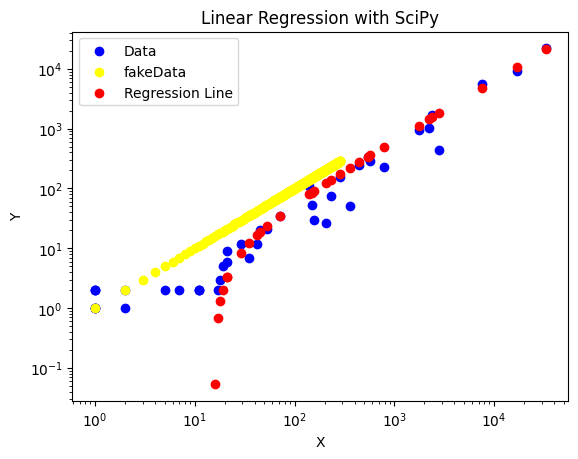

In [87]:
import matplotlib.pyplot as plt

slope, intercept, r_value, p_value, std_err = linregress(col1, col2)

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

plt.scatter(col1, col2, color='blue', label='Data')
#plt.plot(col1, slope * col1 + intercept, color='red', label='Regression Line')
a= np.arange(len(col1))
plt.scatter(a, a, color='yellow', label='fakeData')
sort1= np.sort(col1)
sort1_pos = sort1[slope * sort1 + intercept>0]
plt.plot(sort1_pos, slope * sort1_pos + intercept, color='red', label='Regression Line')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression with SciPy")
plt.show()

In [4]:
sa = np.repeat(np.arange(len(col1)), col1)
b = np.repeat(np.arange(len(col2)), col2)

bins = np.arange(0, len(col1)+1)

hist_x, _ = np.histogram(a, bins=bins, density=True)

a = 0.1907099389212514 b = 1.1188571956939946


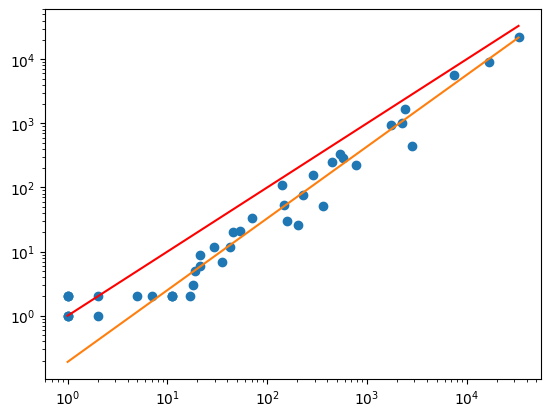

In [142]:
# attempt to power-law the fit

import numpy as np
from scipy.optimize import curve_fit

# power law model
def power_law(x, a, b):
    return a * x**b

# remove neg vals
mask = (col1 > 0) & (col2 > 0)
pos_col1 = col1[mask]
pos_col2 = col2[mask]


# fit
params, cov = curve_fit(power_law, col1, col2)
a, b = params

print("a =", a, "b =", b)

# plot
x_fit = np.linspace(min(col1[mask]), max(col1), 100)
y_fit = power_law(x_fit, a, b)

plt.loglog(col1, col2, 'o')
plt.loglog(x_fit, y_fit)
plt.loglog(x_fit, x_fit, color='red')
plt.show()

a = 1.2013777512164856 b = 1.1188573358954454


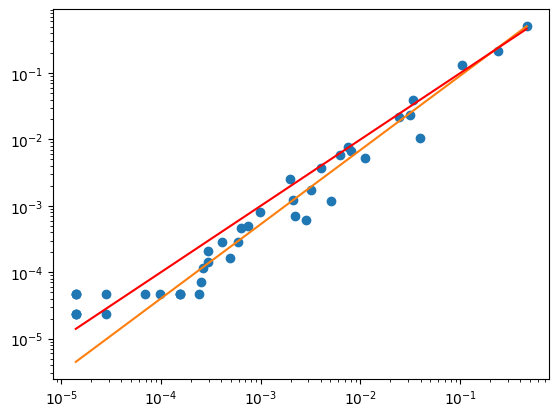

In [144]:
# wait! same with relative frequencies to account for the difference in size of the samples!

# remove neg vals
mask = (col1 > 0) & (col2 > 0)
pos_col1 = col1[mask]
pos_col2 = col2[mask]


# fit
params, cov = curve_fit(power_law, rel_col1, rel_col2)
a, b = params

print("a =", a, "b =", b)

# plot
x_fit = np.linspace(min(rel_col1[mask]), max(rel_col1), 100)
y_fit = power_law(x_fit, a, b)

plt.loglog(rel_col1, rel_col2, 'o')
plt.loglog(x_fit, y_fit)
plt.loglog(x_fit, x_fit, color='red')
plt.show()

In [130]:
print(x_fit, y_fit)

[1.10000000e+000 7.88230615e+013 5.64825002e+027 4.04738508e+041
 2.90024803e+055 2.07824026e+069 1.48921146e+083 1.06712915e+097
 7.64676240e+110 5.47946567e+124 3.92643872e+138 2.81358110e+152
 2.01613705e+166 1.44470996e+180 1.03524056e+194 7.41825731e+207
 5.31572502e+221 3.80910655e+235 2.72950400e+249 1.95588965e+263
 1.40153828e+277 1.00430489e+291 7.19658054e+304             inf
             inf             inf             inf             inf
             inf             inf             inf             inf
             inf             inf             inf             inf
             inf             inf             inf             inf
             inf             inf             inf             inf
             inf             inf             inf             inf
             inf             inf             inf             inf
             inf             inf             inf             inf
             inf             inf             inf             inf
             inf         

In [52]:
print(v)

[  0 288]
